LAPORAN FISIKA KOMPUTASI


Disusun oleh : 
Isma Watu Ridho Baitu R. (01241005)
Muhammad Raichan Nur Firdaus (01241015)
Sesilia Putri Rantetana (01241021)


Dosen Pengampu : 
Agus Rifani, S.Si, M.Si.

 
JURUSAN SAINS DAN ANALITIKA DATA
INSTITUT TEKNOLOGI KALIMANTAN
2026

BAB I
PENDAHULUAN
1.1 Latar Belakang
Aktivitas matahari mengalami perubahan periodik yang dikenal sebagai siklus matahari. Salah satu indikator aktivitas tersebut adalah jumlah sunspot (bintik matahari). Analisis deret waktu ( time series ) dapat digunakan untuk mempelajari pola periodik dan karakteristik siklus matahari menggunakan metode fourier transform.


1.2 Tujuan
Memvisualisasikan data sunspot dalam domain waktu.
Menghilangkan komponen DC pada data.
Melakukan transformasi FFT.
Menganalisis spektrum daya.
Menentukan periode siklus Matahari.


BAB II
 METODOLOGI
2.1 Data 
Data yang digunakan berupa data jumlah sunspot terhadap waktu yang diberikan pada file dataset praktikum.
2.2 Software
Visual Studio Code
Python
NumPy
Pandas
Matplotlib

2.3 Langkah Analisis
Membaca data sunspot
Membuat grafik time series 
Menghilangkan nilai rata rata 
Melakukan FTT
Membuat power spectrum
Menentukan frekuensi dominan dan periode siklus


BAB III 
HASIL DAN PEMBAHASAN

3.1 Data Loading and Time-Domain Visualization
Source code

Number of data points = 3252

===== DATA STATISTICS =====
Maximum Sunspot Number = 398.20
Minimum Sunspot Number = 0.00
Mean Sunspot Number    = 82.07
Standard Deviation     = 67.85

===== RESULTS =====
Dominant Frequency = 0.09225 cycles/year
Dominant Solar Cycle = 10.84 years


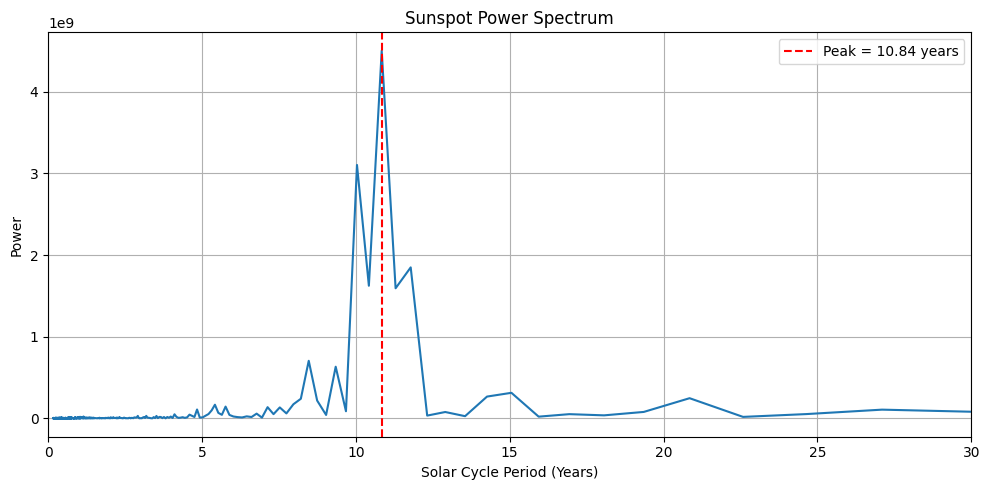

In [1]:
# =====================================================
# CASE 1 - ASTROPHYSICS
# TASK 1-5 (ALL IN ONE)
# =====================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------------------------------
# TASK 1 : LOAD DATA
# -----------------------------------------------------

data = pd.read_csv("sunspots.csv")

if "Date" in data.columns:
    data["Date"] = pd.to_datetime(data["Date"])
    y = data["Monthly Mean Total Sunspot Number"].values
else:
    y = data["Sunspot_Count"].values

print(f"Number of data points = {len(y)}")

# -----------------------------------------------------
# TASK 2 : REMOVE DC COMPONENT
# -----------------------------------------------------

y_centered = y - np.mean(y)

# -----------------------------------------------------
# TASK 3 : FFT
# -----------------------------------------------------

N = len(y_centered)

# Statistik dasar
y_max = np.max(y)
y_min = np.min(y)
y_mean = np.mean(y)
y_std = np.std(y)

print("\n===== DATA STATISTICS =====")
print(f"Maximum Sunspot Number = {y_max:.2f}")
print(f"Minimum Sunspot Number = {y_min:.2f}")
print(f"Mean Sunspot Number    = {y_mean:.2f}")
print(f"Standard Deviation     = {y_std:.2f}")

# Data bulanan -> sampling interval 1/12 tahun
dt = 1/12

Y = np.fft.rfft(y_centered)
freq = np.fft.rfftfreq(N, d=dt)

# -----------------------------------------------------
# TASK 4 : POWER SPECTRUM
# -----------------------------------------------------

power = np.abs(Y)**2

# Hilangkan frekuensi nol
freq = freq[1:]
power = power[1:]

# Konversi ke periode (tahun)
period = 1 / freq

# -----------------------------------------------------
# TASK 5 : DOMINANT SOLAR CYCLE
# -----------------------------------------------------

peak_idx = np.argmax(power)

dominant_period = period[peak_idx]
dominant_frequency = freq[peak_idx]

print("\n===== RESULTS =====")
print(f"Dominant Frequency = {dominant_frequency:.5f} cycles/year")
print(f"Dominant Solar Cycle = {dominant_period:.2f} years")

# -----------------------------------------------------
# FINAL GRAPH
# -----------------------------------------------------

plt.figure(figsize=(10,5))

plt.plot(period, power, linewidth=1.5)

plt.axvline(
    dominant_period,
    color='red',
    linestyle='--',
    label=f'Peak = {dominant_period:.2f} years'
)

plt.xlim(0,30)

plt.xlabel("Solar Cycle Period (Years)")
plt.ylabel("Power")
plt.title("Sunspot Power Spectrum")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Pembahasan
Program berhasil membaca data sunspot sebanyak 3252 dan melakukan analisis menggunakan metode Fast Fourier Transform untuk mengidentifikasi siklus dominan aktivitas matahari. Sebelum FTT dilakukan, data dikurangi dengan nilai rata ratanya agar komponen frekuensi nol tidak mempengaruhi hasil analisis 
Berdasarkan output program diperoleh frekuensi dominan sebesar 0,09225 siklus/tahun. Nilai ini menunjukkan bahwa pola aktivitas Matahari berulang setiap sekitar 10,84 tahun.
	Pada grafik Sunspot Power Spectrum terlihat puncak tertinggi berada pada periode sekitar 10,84 tahun, yang ditandai dengan garis merah putus-putus. Puncak ini memiliki nilai power terbesar dibandingkan periode lainnya, sehingga menunjukkan bahwa periode tersebut merupakan siklus yang paling dominan dalam data sunspot.
	Hasil yang diperoleh sangat sesuai dengan teori Solar Cycle, yaitu siklus aktivitas Matahari yang memiliki periode rata-rata sekitar 11 tahun. Kedekatan hasil perhitungan dengan nilai teoritis menunjukkan bahwa metode FFT mampu mengidentifikasi karakteristik periodik data sunspot dengan baik. Oleh karena itu, dapat disimpulkan bahwa data yang dianalisis mengandung siklus utama aktivitas Matahari dengan periode sekitar 10,84 tahun.


3.2 ANALISIS STATISTIK
Untuk mengetahui karakteristik umum data sunspot yang digunakan, dilakukan analisis statistik deskriptif yang meliputi nilai maksimum, nilai minimum, rata-rata, dan standar deviasi

Parameter
Nilai
Jumlah data
3252
Nilai Maksimum
398.20
Nilai Minimum
0.00
Rata-Rata
82.07
Standar Deviasi
67.85


Berdasarkan tabel data sunspot memiliki nilai maksimum sebesar 398.20 dan nilai minimum sebesar 0.00. Perbedaan antara nilai maksimum dan minimum tersebut menunjukkan bahwa aktivitas Matahari mengalami perubahan yang cukup besar selama periode pengamatan. Nilai rata-rata sebesar 82.07 menunjukkan jumlah sunspot rata-rata yang teramati pada seluruh data, sedangkan standar deviasi sebesar 67.85 menunjukkan tingkat penyebaran data terhadap nilai rata-ratanya. Semakin besar nilai standar deviasi, semakin besar pula variasi aktivitas Matahari yang terjadi dari waktu ke waktu.
Rentang nilai yang cukup besar antara nilai maksimum dan minimum menunjukkan bahwa aktivitas Matahari tidak bersifat konstan, melainkan mengalami kenaikan dan penurunan secara periodik. Variasi inilah yang menjadi dasar dilakukannya analisis lebih lanjut menggunakan metode Fast Fourier Transform untuk mengidentifikasi siklus dominan yang terkandung dalam data sunspot. Dengan demikian, analisis statistik deskriptif memberikan gambaran awal mengenai karakteristik data sebelum dilakukan analisis frekuensi untuk mendapatkan periode aktivitas Matahari yang dominan. 

BAB IV
PENUTUP

4.1 Kesimpulan
Data sunspot menunjukkan pola periodik yang menggambarkan aktivitas Matahari.
Visualisasi data berhasil menampilkan siklus naik dan turun jumlah sunspot.
Analisis time series dapat digunakan untuk mempelajari karakteristik solar cycle.

4.2 Saran
Dalam pengerjaan studi kasus ini masih terdapat keterbatasan dalam analisis data dan visualisasi hasil. Oleh karena itu, pada pengembangan selanjutnya dapat dilakukan eksplorasi metode analisis yang lebih beragam serta interpretasi data yang lebih mendalam untuk meningkatkan kualitas hasil yang diperoleh. 


LAMPIRAN
Penggunaan AI : 
	Github Co-Pilot	 : Digunakan sebagai asisten pemrograman untuk memberikan saran penulisan kode secara otomatis, melengkapi sintaks Python, mempercepat pembuatan fungsi analisis data, serta membantu proses debugging selama pengembangan program. 
Chat-GPT 		: Digunakan sebagai asisten pemrograman untuk memberikan saran penulisan kode secara otomatis, melengkapi sintaks Python, mempercepat pembuatan fungsi analisis data, serta membantu proses debugging selama pengembangan program. 

Penggunaan Perangkat Lunak : 
Python 		: Digunakan sebagai bahasa pemrograman utama untuk pengolahan dan analisis data sunspot.
Jupyter Notebook : Digunakan sebagai lingkungan kerja untuk menjalankan program, menampilkan hasil analisis, dan visualisasi data.
Pandas 		: Digunakan untuk membaca serta mengelola data dari file CSV.
NumPy 		: Digunakan untuk perhitungan numerik dan implementasi Fast Fourier Transform (FFT).
Matplotlib 		: Digunakan untuk membuat grafik dan visualisasi spektrum daya (Power Spectrum).